<a href="https://colab.research.google.com/github/bhatturvashi2618-sketch/capstoneproject2/blob/main/loan_approval.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Business Understanding
## Project Overview

Banks need to identify customers who are likely to default on loans before approval. Incorrect lending decisions can lead to financial losses. The goal of this project is to build a machine learning model that predicts loan default using customer and loan information, helping banks reduce risk and make better lending decisions.

## Problem Statement

Develop a machine learning model to predict whether a loan applicant is likely to default based on historical customer and loan data.

##Objective

Predict loan default.
Reduce financial losses.
Support better loan approval decisions.

![](https://raw.githubusercontent.com/bhatturvashi2618-sketch/capstoneproject2/main/loanapproval.png)



**Import Libraries**

In [ ]:
#Data Manipulation
import pandas as pd
import numpy as np

In [ ]:
#Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#Ignore Warnings
import warnings
warnings.filterwarnings('ignore')

In [ ]:
#Data Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

In [ ]:
#Handle Missing Values
from sklearn.impute import SimpleImputer

In [ ]:
!pip install xgboost
#Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier

In [ ]:
#Model Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

In [ ]:
#Hyperparameter Tuning
from sklearn.model_selection import RandomizedSearchCV

In [ ]:
#Cross Validation
from sklearn.model_selection import cross_val_score

In [ ]:
#Feature Importance
from sklearn.inspection import permutation_importance

In [ ]:
#Explainable AI (Optional but Recommended)
import shap

In [ ]:
#Save the Model
import joblib

#Data Source

The dataset used in this project was obtained from Kaggle. It is a publicly available Loan Approval Prediction dataset provided in CSV format.
The data was imported into Python using the Pandas library for preprocessing, exploratory data analysis, and machine learning model development.

#Constraints

The dataset contains missing values that require preprocessing.
Some categorical features must be encoded before model training.
The dataset is relatively small, so careful validation is needed to avoid overfitting.
The data is intended for educational and research purposes and may not fully represent real-world banking scenarios.

In [ ]:
# Setting this option will print all collumns of a dataframe
pd.set_option('display.max_columns', None)
# Setting this option will print all of the data in a feature
pd.set_option('display.max_colwidth', None)

In [123]:
import pandas as pd
accepted_df = pd.read_csv('/content/sample_data/accepted_2007_to_2018Q4.csv', nrows=10000)
display(accepted_df.head())

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,fico_range_low,fico_range_high,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,last_fico_range_high,last_fico_range_low,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_act_il,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m,acc_open_past_24mths,avg_cur_bal,bc_open_to_buy,bc_util,chargeoff_within_12_mths,delinq_amnt,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,mths_since_recent_bc_dlq,mths_since_recent_inq,mths_since_recent_revol_delinq,num_accts_ever_120_pd,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,revol_bal_joint,sec_app_fico_range_low,sec_app_fico_range_high,sec_app_earliest_cr_line,sec_app_inq_last_6mths,sec_app_mort_acc,sec_app_open_acc,sec_app_revol_util,sec_app_open_act_il,sec_app_num_rev_accts,sec_app_chargeoff_within_12_mths,sec_app_collections_12_mths_ex_med,sec_app_mths_since_last_major_derog,hardship_flag,hardship_type,hardship_reason,hardship_status,deferral_term,hardship_amount,hardship_start_date,hardship_end_date,payment_plan_start_date,hardship_length,hardship_dpd,hardship_loan_status,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,leadman,10+ years,MORTGAGE,55000.0,Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.action?loan_id=68407277,NaN,debt_consolidation,Debt consolidation,190xx,PA,5.91,0.0,Aug-2003,675.0,679.0,1.0,30.0,NaN,7.0,0.0,2765.0,29.7,13.0,w,0.00,0.00,4421.723917,4421.72,3600.00,821.72,0.0,0.0,0.0,Jan-2019,122.67,NaN,Mar-2019,564.0,560.0,0.0,30.0,1.0,Individual,NaN,NaN,NaN,0.0,722.0,144904.0,2.0,2.0,0.0,1.0,21.0,4981.0,36.0,3.0,3.0,722.0,34.0,9300.0,3.0,1.0,4.0,4.0,20701.0,1506.0,37.2,0.0,0.0,148.0,128.0,3.0,3.0,1.0,4.0,69.0,4.0,69.0,2.0,2.0,4.0,2.0,5.0,3.0,4.0,9.0,4.0,7.0,0.0,0.0,0.0,3.0,76.9,0.0,0.0,0.0,178050.0,7746.0,2400.0,13734.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,Engineer,10+ years,MORTGAGE,65000.0,Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.action?loan_id=68355089,NaN,small_business,Business,577xx,SD,16.06,1.0,Dec-1999,715.0,719.0,4.0,6.0,NaN,22.0,0.0,21470.0,19.2,38.0,w,0.00,0.00,25679.660000,25679.66,24700.00,979.66,0.0,0.0,0.0,Jun-2016,926.35,NaN,Mar-2019,699.0,695.0,0.0,NaN,1.0,Individual,NaN,NaN,NaN,0.0,0.0,204396.0,1.0,1.0,0.0,1.0,19.0,18005.0,73.0,2.0,3.0,6472.0,29.0,111800.0,0.0,0.0,6.0,4.0,9733.0,57830.0,27.1,0.0,0.0,113.0,192.0,2.0,2.0,4.0,2.0,NaN,0.0,6.0,0.0,5.0,5.0,13.0,17.0,6.0,20.0,27.0,5.0,22.0,0.0,0.0,0.0,2.0,97.4,7.7,0.0,0.0,314017.0,39475.0,79300

In [ ]:
import pandas as pd
rejected_df = pd.read_csv('/content/sample_data/rejected_2007_to_2018Q4.csv', nrows=10000)
display(rejected_df.head())

,Amount Requested,Application Date,Loan Title,Risk_Score,Debt-To-Income Ratio,Zip Code,State,Employment Length,Policy Code
0,1000.0,2007-05-26,Wedding Covered but No Honeymoon,693.0,10%,481xx,NM,4 years,0.0
1,1000.0,2007-05-26,Consolidating Debt,703.0,10%,010xx,MA,< 1 year,0.0
2,11000.0,2007-05-27,Want to consolidate my debt,715.0,10%,212xx,MD,1 year,0.0
3,6000.0,2007-05-27,waksman,698.0,38.64%,017xx,MA,< 1 year,0.0
4,1500.0,2007-05-27,mdrigo,509.0,9.43%,209xx,MD,< 1 year,0.0


#Data Dictionary
The dataset contains over 140 features, including borrower demographics, employment information, loan details, credit history, repayment records, and account balances. For brevity, only the key variables used in model development are described in this report.

#Exploratory Data Analysis (EDA) & Preprocessing

In [ ]:
#Identifiers such as id, member_id, url, and desc do not help the model learn patterns. They are unique for each loan or contain unnecessary text, so they should be removed.
# Drop identifier columns
columns_to_drop = [
    'id', 'member_id', 'url', 'desc', 'title', 'emp_title',

    'out_prncp', 'out_prncp_inv',
    'total_pymnt', 'total_pymnt_inv',
    'total_rec_prncp', 'total_rec_int',
    'total_rec_late_fee', 'recoveries',
    'collection_recovery_fee',
    'last_pymnt_d', 'last_pymnt_amnt',
    'next_pymnt_d', 'last_credit_pull_d',
    'last_fico_range_high', 'last_fico_range_low',

    'hardship_flag', 'hardship_type', 'hardship_reason',
    'hardship_status', 'deferral_term',
    'hardship_amount', 'hardship_start_date',
    'hardship_end_date', 'payment_plan_start_date',
    'hardship_length', 'hardship_dpd',
    'hardship_loan_status',
    'orig_projected_additional_accrued_interest',
    'hardship_payoff_balance_amount',
    'hardship_last_payment_amount',

    'debt_settlement_flag',
    'debt_settlement_flag_date',
    'settlement_status',
    'settlement_date',
    'settlement_amount',
    'settlement_percentage',
    'settlement_term'
]

accepted_df.drop(columns=columns_to_drop, inplace=True, errors='ignore')
rejected_df.drop(columns=['Loan Title', 'Policy Code'], inplace=True, errors='ignore')

In [ ]:
print('Columns in accepted_df:')
print(accepted_df.columns.tolist())

Columns in accepted_df:
['loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d', 'loan_status', 'pymnt_plan', 'purpose', 'zip_code', 'addr_state', 'dti', 'delinq_2yrs', 'earliest_cr_line', 'fico_range_low', 'fico_range_high', 'inq_last_6mths', 'mths_since_last_delinq', 'mths_since_last_record', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'initial_list_status', 'collections_12_mths_ex_med', 'mths_since_last_major_derog', 'policy_code', 'application_type', 'annual_inc_joint', 'dti_joint', 'verification_status_joint', 'acc_now_delinq', 'tot_coll_amt', 'tot_cur_bal', 'open_acc_6m', 'open_act_il', 'open_il_12m', 'open_il_24m', 'mths_since_rcnt_il', 'total_bal_il', 'il_util', 'open_rv_12m', 'open_rv_24m', 'max_bal_bc', 'all_util', 'total_rev_hi_lim', 'inq_fi', 'total_cu_tl', 'inq_last_12m', 'acc_open_past_24mths', 'avg_cur_bal', 'bc_open_to_buy', 

In [ ]:
print('Columns in rejected_df:')
print(rejected_df.columns.tolist())

Columns in rejected_df:
['Amount Requested', 'Application Date', 'Risk_Score', 'Debt-To-Income Ratio', 'Zip Code', 'State', 'Employment Length']


In [ ]:
missing = pd.DataFrame({
    'Missing Values': accepted_df.isnull().sum(),
    'Percentage': (accepted_df.isnull().sum() / len(accepted_df)) * 100
})

missing = missing[missing['Missing Values'] > 0]
missing.sort_values('Percentage', ascending=False)

,Missing Values,Percentage
il_util,1250,12.50
mths_since_recent_inq,1073,10.73
num_tl_120dpd_2m,563,5.63
emp_length,549,5.49
mths_since_rcnt_il,240,2.40
mo_sin_old_il_acct,239,2.39
bc_util,107,1.07
percent_bc_gt_75,105,1.05
bc_open_to_buy,99,0.99
mths_since_recent_bc,96,0.96


In [ ]:
missing = pd.DataFrame({
    'Missing Values': rejected_df.isnull().sum(),
    'Percentage': (rejected_df.isnull().sum() / len(rejected_df)) * 100
})

missing = missing[missing['Missing Values'] > 0]
missing.sort_values('Percentage', ascending=False)

,Missing Values,Percentage
Risk_Score,343,3.43


In [ ]:
#drop columns that have more than 70% of missing values
columns_to_drop = [
'sec_app_inq_last_6mths'	,
'sec_app_inq_last_6mths'	,
'sec_app_fico_range_high'	,
'sec_app_fico_range_low'	,
'sec_app_num_rev_accts'	,
'sec_app_chargeoff_within_12_mths'	,
'sec_app_collections_12_mths_ex_med'	,
'sec_app_open_act_il'	,
'sec_app_mths_since_last_major_derog'	,
'sec_app_revol_util'	,
'sec_app_open_acc'	,
'sec_app_mort_acc'	,
'revol_bal_joint'	,
'annual_inc_joint'	,
'verification_status_joint'	,
'dti_joint'	,
'mths_since_last_record'	,
'mths_since_recent_bc_dlq'	,
'mths_since_last_major_derog'


]

accepted_df.drop(columns=columns_to_drop, inplace=True, errors='ignore')


#axis=1 → Drop columns.
#thresh=threshold → Keep columns that have at least 70% non-missing values.
threshold = len(accepted_df) * 0.7
accepted_df = accepted_df.dropna(axis=1, thresh=threshold)

threshold = len(rejected_df) * 0.7
rejected_df = rejected_df.dropna(axis=1, thresh=threshold)

In [ ]:
missing = (accepted_df.isnull().sum() / len(accepted_df)) * 100
missing.sort_values(ascending=False)

,0
emp_length,5.49
mths_since_rcnt_il,2.40
mo_sin_old_il_acct,2.39
bc_util,1.07
percent_bc_gt_75,1.05
...,...
tot_hi_cred_lim,0.00
total_bal_ex_mort,0.00
total_bc_limit,0.00
total_il_high_credit_limit,0.00


In [ ]:
missing = (rejected_df.isnull().sum() / len(rejected_df)) * 100
missing.sort_values(ascending=False)

,0
Risk_Score,3.43
Amount Requested,0.00
Application Date,0.00
Debt-To-Income Ratio,0.00
Zip Code,0.00
State,0.00
Employment Length,0.00


Check the Distribution of Numerical Columns

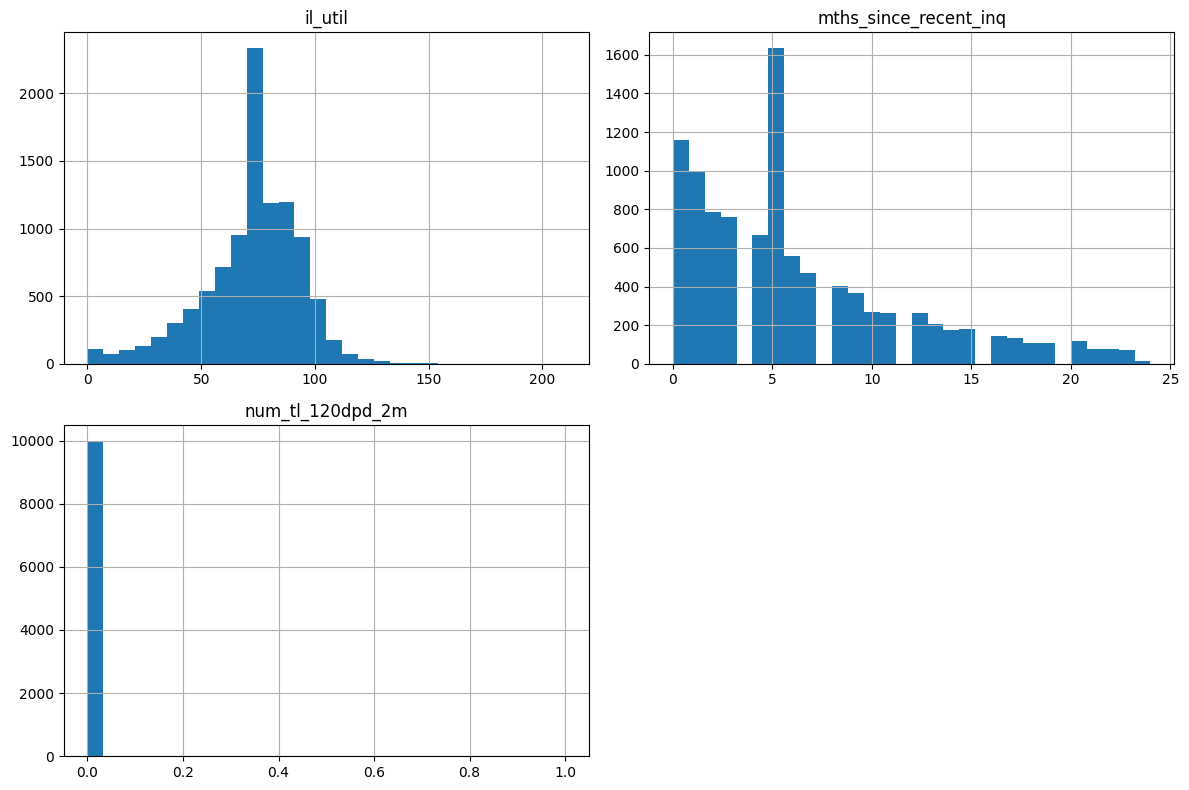

In [ ]:
columns = [
'il_util',
'mths_since_recent_inq',
'num_tl_120dpd_2m'
]

accepted_df[columns].hist(figsize=(12, 8), bins=30)
plt.tight_layout()
plt.show()
#data is skewed

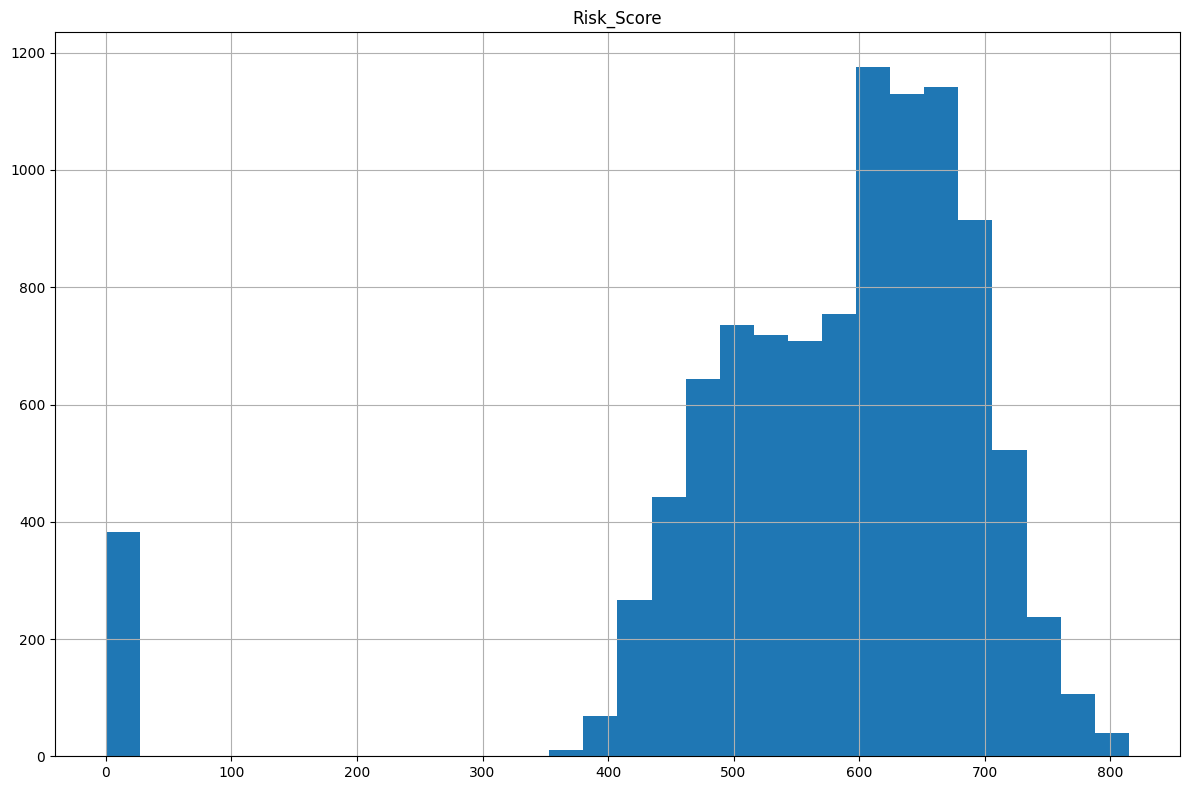

In [ ]:
columns = [
'Risk_Score'
]

rejected_df[columns].hist(figsize=(12, 8), bins=30)
plt.tight_layout()
plt.show()

In [ ]:
#check for skewness
print("il_util:", accepted_df['il_util'].skew())
print("mths_since_recent_inq:", accepted_df['mths_since_recent_inq'].skew())
print("num_tl_120dpd_2m:", accepted_df['num_tl_120dpd_2m'].skew())
print("num_tl_120dpd_2m:", accepted_df['num_tl_120dpd_2m'].skew())
print("Risk_Score:", rejected_df['Risk_Score'].skew())

il_util: -0.7451427490635532
mths_since_recent_inq: 1.1454030644241022
num_tl_120dpd_2m: 57.717700924471174
num_tl_120dpd_2m: 57.717700924471174
Risk_Score: -2.3023115947902157


In [ ]:
accepted_df['il_util'] = accepted_df['il_util'].fillna(accepted_df['il_util'].median())
accepted_df['mths_since_recent_inq'] = accepted_df['mths_since_recent_inq'].fillna(accepted_df['mths_since_recent_inq'].median())
rejected_df['Risk_Score'] = rejected_df['Risk_Score'].fillna(rejected_df['Risk_Score'].median())

In [ ]:
#check for duplicates
accepted_df.duplicated().sum()

np.int64(0)

In [ ]:
rejected_df.duplicated().sum()

np.int64(0)

In [ ]:
#if exists
accepted_df.drop_duplicates(inplace=True)

In [ ]:
rejected_df.drop_duplicates(inplace=True)

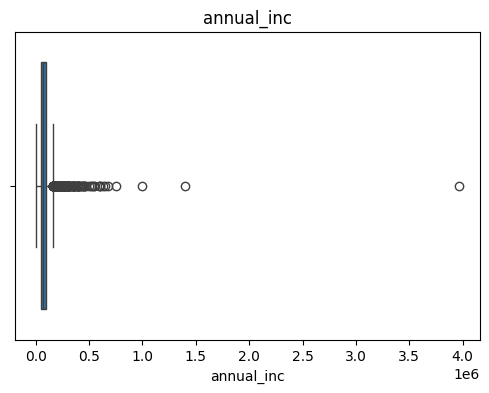

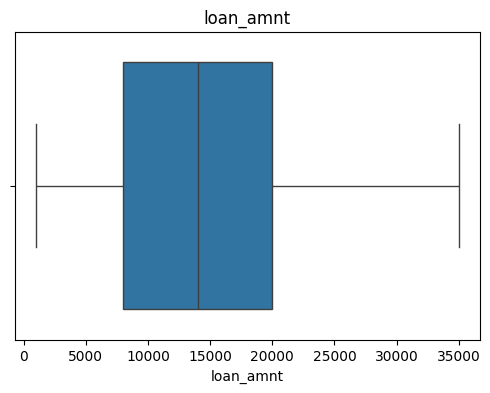

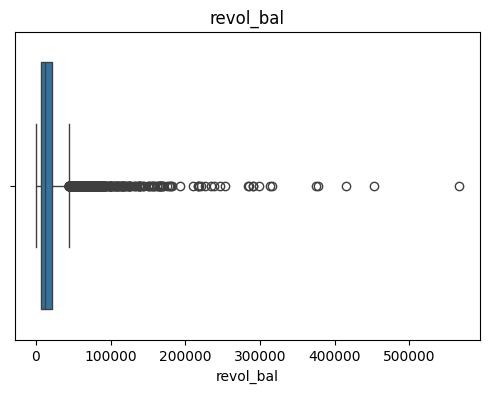

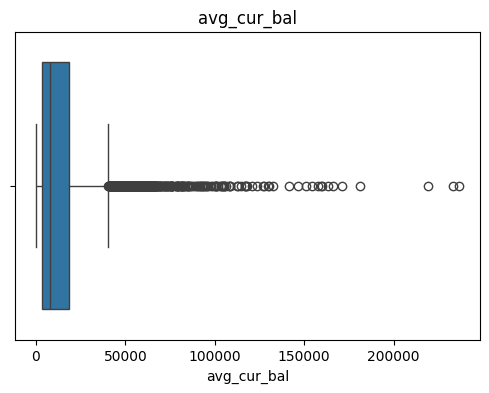

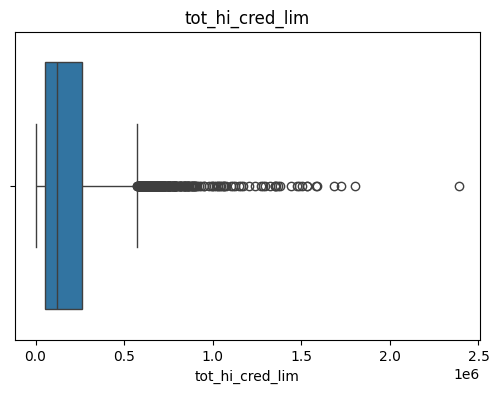

In [ ]:
#identify outliers
import seaborn as sns
import matplotlib.pyplot as plt

cols = [
    'annual_inc',
    'loan_amnt',
    'revol_bal',
    'avg_cur_bal',
    'tot_hi_cred_lim'
]

for col in cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=accepted_df[col])
    plt.title(col)
    plt.show()

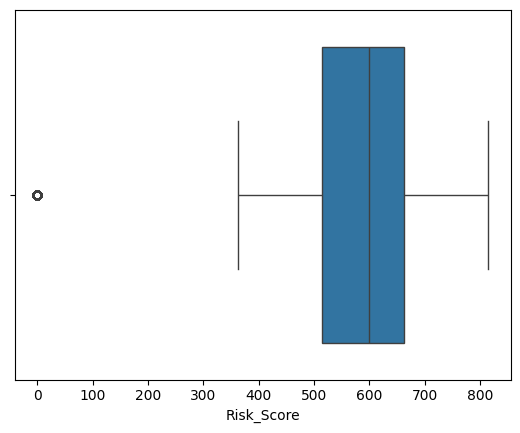

In [ ]:
import seaborn as sns

sns.boxplot(x=rejected_df['Risk_Score'])
plt.show()

In [ ]:
#nvestigate whether a score of 0 is valid.
rejected_df[rejected_df['Risk_Score'] == 0]

,Amount Requested,Application Date,Risk_Score,Debt-To-Income Ratio,Zip Code,State,Employment Length


In [ ]:
#Check whether 0 is a valid value
rejected_df['Risk_Score'].describe()


,Risk_Score
count,9996.000000
mean,595.979792
std,86.877500
min,363.000000
25%,530.000000
50%,601.000000
75%,662.000000
max,815.000000


In [ ]:
import numpy as np

# Replace 0 with NaN
rejected_df['Risk_Score'] = rejected_df['Risk_Score'].replace(0, np.nan)

# Impute with median
rejected_df['Risk_Score'] = rejected_df['Risk_Score'].fillna(rejected_df['Risk_Score'].median())

In [ ]:
#verify
print(rejected_df['Risk_Score'].min())
print(rejected_df['Risk_Score'].isnull().sum())

363.0
0


In [ ]:
#check for the skew ness
rejected_df['Risk_Score'].skew()

np.float64(-0.2214949401307532)

In [ ]:
#shape before capping
print(accepted_df.shape)

(10000, 87)


In [ ]:
#capping the outliars
columns = [
    'revol_bal',
    'avg_cur_bal',
    'tot_hi_cred_lim'
]

for col in columns:
    Q1 = accepted_df[col].quantile(0.25)
    Q3 = accepted_df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    accepted_df[col] = accepted_df[col].clip(lower=lower, upper=upper)

In [ ]:
#shape after capping
print(accepted_df.shape)

(10000, 87)


In [ ]:
#check for catogorical data
cat_cols = accepted_df.select_dtypes(include=['object', 'category']).columns

print(cat_cols.tolist())

[]


In [ ]:
cat_cols = rejected_df.select_dtypes(include=['object', 'category']).columns

print(cat_cols.tolist())

[]


In [ ]:
#encoding the categorical data
rejected_df = pd.get_dummies(rejected_df, columns=['Application Date', 'Debt-To-Income Ratio', 'Zip Code', 'State', 'Employment Length'], drop_first=True)

In [ ]:
#check data types
accepted_df.dtypes


,0
loan_amnt,float64
funded_amnt,float64
funded_amnt_inv,float64
int_rate,float64
installment,float64
...,...
earliest_cr_line_Sep-2010,bool
earliest_cr_line_Sep-2011,bool
earliest_cr_line_Sep-2012,bool
initial_list_status_w,bool


In [ ]:
rejected_df.dtypes

,0
Amount Requested,float64
Risk_Score,float64
Application Date_2007-05-27,bool
Application Date_2007-05-28,bool
Application Date_2007-05-29,bool
...,...
Employment Length_6 years,bool
Employment Length_7 years,bool
Employment Length_8 years,bool
Employment Length_9 years,bool


In [ ]:
#Separate features and target
X = accepted_df.drop('loan_status', axis=1)
y = accepted_df['loan_status']

X = rejected_df.drop('loan_status', axis=1)
y = rejected_df['loan_status']

KeyError: "['loan_status'] not found in axis"